# Notebook 5 — Bayesian Confidence Layer

| Trường | Nội dung |
| --- | --- |
| **Dự án** | Bayesian Uncertainty-Aware Financial Risk Forecasting |
| **Notebook** | 5 of 7 |
| **Input** | `data/processed/validation_predictions.csv` (từ NB4) |
| **Output** | `data/processed/bayesian_decision_dataset.csv` · `results/bayesian/bayesian_threshold.json` · figures `reports/figures/nb5/` |
| **Trọng tâm** | Threshold Optimization (F2) · Confidence Score · Uncertainty Validation |

## 1. Import & Cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import os
from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    accuracy_score, precision_recall_curve, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='darkgrid', palette='muted')

FIGURES_DIR  = '../reports/figures/nb5'
RESULTS_DIR  = '../results/bayesian'
PROCESSED_DIR = '../data/processed'

os.makedirs(FIGURES_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR,  exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('✓ Imports OK')

✓ Imports OK


## 2. Load validation predictions từ NB4

In [2]:
df = pd.read_csv(
    f'{PROCESSED_DIR}/validation_predictions.csv',
    parse_dates=['Date'], index_col='Date'
)

print(f'Shape         : {df.shape}')
print(f'Date range    : {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns       : {list(df.columns)}')
print(f'Class balance : {df["Actual"].value_counts(normalize=True).round(3).to_dict()}')
print(f'Pred Mean     : [{df["Predictive_Mean"].min():.4f}, {df["Predictive_Mean"].max():.4f}]')
print(f'Pred Var      : [{df["Predictive_Variance"].min():.6f}, {df["Predictive_Variance"].max():.6f}]')
print()
print(df.head(10).round(6).to_string())

Shape         : (477, 6)
Date range    : 2021-03-15 → 2023-02-02
Columns       : ['Actual', 'Predictive_Mean', 'Predictive_Variance', 'CI_Lower', 'CI_Upper', 'CI_Width']
Class balance : {0: 0.778, 1: 0.222}
Pred Mean     : [0.0391, 0.7409]
Pred Var      : [0.000288, 0.042796]

            Actual  Predictive_Mean  Predictive_Variance  CI_Lower  CI_Upper  CI_Width
Date                                                                                  
2021-03-15       0         0.176466             0.002279  0.098850  0.280394  0.181544
2021-03-16       0         0.160339             0.001568  0.095362  0.244008  0.148646
2021-03-17       1         0.175776             0.001581  0.108982  0.260927  0.151945
2021-03-18       0         0.203174             0.003265  0.109544  0.329133  0.219589
2021-03-19       0         0.211004             0.003297  0.111967  0.335322  0.223355
2021-03-22       0         0.139330             0.001720  0.074918  0.231746  0.156828
2021-03-23       0        

## 3. Phase 1 — Threshold Optimization

$$\hat{y} = \mathbb{1}[\pi(x^*) \geq \tau]$$

Tối ưu $\tau$ theo **F2 Score** ($\beta = 2$).

### Tại sao F2 thay vì F1?

**F1** coi Precision và Recall ngang bằng nhau ($\beta = 1$):

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**F2** cho Recall trọng số **gấp đôi** Precision ($\beta = 2$):

$$F_2 = \frac{(1 + \beta^2) \cdot \text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}} = \frac{5 \cdot \text{Precision} \cdot \text{Recall}}{4 \cdot \text{Precision} + \text{Recall}}$$

**Lý do chọn F2 trong bài toán tài chính:**
- **Miss một biến động mạnh (False Negative)** → bỏ lỡ tín hiệu rủi ro, hậu quả nghiêm trọng.
- **Cảnh báo nhầm (False Positive)** → chỉ tốn chi phí giao dịch, ít nguy hiểm hơn.
- F2 ưu tiên Recall → mô hình cảnh báo nhiều hơn, phù hợp với mục tiêu quản lý rủi ro.

Ngoài ra, Accuracy bị bias bởi class imbalance (~24% positive) → không phù hợp làm metric tối ưu.

In [3]:
y_true = df['Actual'].values
y_prob = df['Predictive_Mean'].values

thresholds = np.arange(0.10, 0.91, 0.01)
results = []

for tau in thresholds:
    y_pred = (y_prob >= tau).astype(int)
    if y_pred.sum() == 0:
        results.append({
            'threshold': round(tau, 2),
            'precision': 0.0, 'recall': 0.0,
            'f1': 0.0, 'f2': 0.0, 'n_pos': 0
        })
        continue
    results.append({
        'threshold': round(tau, 2),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'f2'       : fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'n_pos'    : int(y_pred.sum())
    })

thr_df = pd.DataFrame(results)

# Tối ưu theo F2
best_idx       = thr_df['f2'].idxmax()
BEST_THRESHOLD = float(thr_df.loc[best_idx, 'threshold'])
best_f2        = float(thr_df.loc[best_idx, 'f2'])
best_f1        = float(thr_df.loc[best_idx, 'f1'])
best_precision = float(thr_df.loc[best_idx, 'precision'])
best_recall    = float(thr_df.loc[best_idx, 'recall'])

print('=== Threshold Optimization Results (F2, β=2) ===')
print(f'Best threshold : {BEST_THRESHOLD}')
print(f'Best F2        : {best_f2:.4f}  ← optimized metric')
print(f'Best F1        : {best_f1:.4f}  (tham khảo)')
print(f'Precision      : {best_precision:.4f}')
print(f'Recall         : {best_recall:.4f}')
print(f'N predicted +  : {int(thr_df.loc[best_idx, "n_pos"])}')

=== Threshold Optimization Results (F2, β=2) ===
Best threshold : 0.17
Best F2        : 0.6213  ← optimized metric
Best F1        : 0.4693  (tham khảo)
Precision      : 0.3333
Recall         : 0.7925
N predicted +  : 252


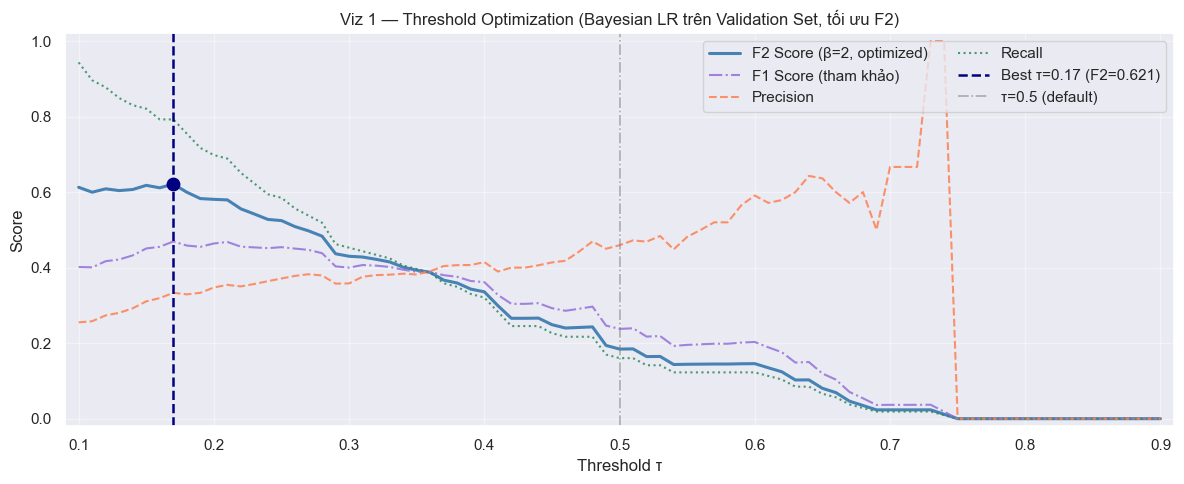

Saved → ../reports/figures/nb5/viz1_threshold_f2.png


In [4]:
# ── Viz 1: Threshold vs F2/F1/Precision/Recall ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(thr_df['threshold'], thr_df['f2'],        color='steelblue',    lw=2.2, label='F2 Score (β=2, optimized)')
ax.plot(thr_df['threshold'], thr_df['f1'],        color='mediumpurple', lw=1.5, ls='-.', label='F1 Score (tham khảo)', alpha=0.85)
ax.plot(thr_df['threshold'], thr_df['precision'],  color='coral',        lw=1.5, ls='--', label='Precision', alpha=0.85)
ax.plot(thr_df['threshold'], thr_df['recall'],     color='seagreen',     lw=1.5, ls=':',  label='Recall', alpha=0.85)
ax.axvline(BEST_THRESHOLD, color='navy', lw=1.8, ls='--',
           label=f'Best τ={BEST_THRESHOLD} (F2={best_f2:.3f})')
ax.axvline(0.5, color='gray', lw=1.2, ls='-.', alpha=0.6, label='τ=0.5 (default)')
ax.scatter([BEST_THRESHOLD], [best_f2], color='navy', s=80, zorder=5)

ax.set_title('Viz 1 — Threshold Optimization (Bayesian LR trên Validation Set, tối ưu F2)', fontsize=12)
ax.set_xlabel('Threshold τ')
ax.set_ylabel('Score')
ax.set_xlim(0.09, 0.91)
ax.set_ylim(-0.02, 1.02)
ax.legend(ncol=2)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz1_threshold_f2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz1_threshold_f2.png')

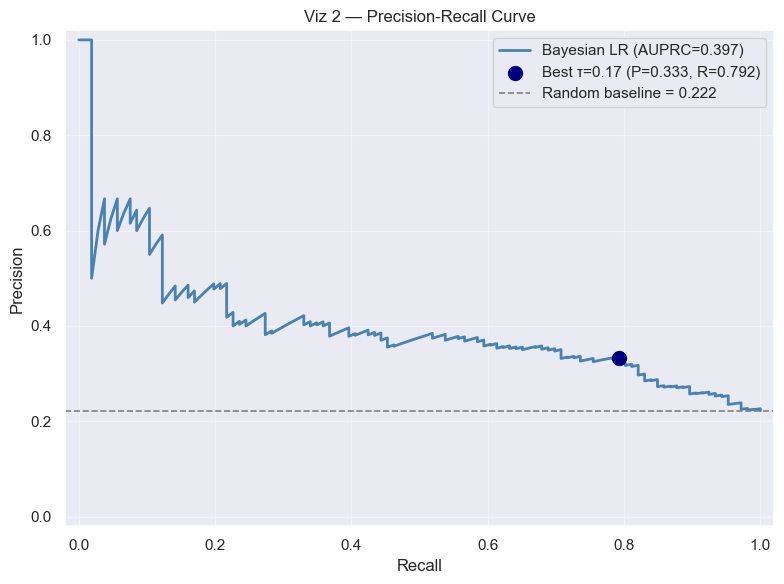

AUPRC=0.3970 | Baseline=0.2222


In [5]:
# ── Viz 2: Precision-Recall Curve ───────────────────────────────────────────
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
auprc = auc(rec_curve, prec_curve)
baseline_rate = y_true.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_curve, prec_curve, color='steelblue', lw=2,
        label=f'Bayesian LR (AUPRC={auprc:.3f})')

best_pred = (y_prob >= BEST_THRESHOLD).astype(int)
bp = precision_score(y_true, best_pred, zero_division=0)
br = recall_score(y_true, best_pred, zero_division=0)
ax.scatter([br], [bp], color='navy', s=100, zorder=5,
           label=f'Best τ={BEST_THRESHOLD} (P={bp:.3f}, R={br:.3f})')

ax.axhline(baseline_rate, color='gray', lw=1.2, ls='--',
           label=f'Random baseline = {baseline_rate:.3f}')

ax.set_title('Viz 2 — Precision-Recall Curve', fontsize=12)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz2_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUPRC={auprc:.4f} | Baseline={baseline_rate:.4f}')

In [6]:
# ============================================================
# Uncertainty = Width of 95% Credible Interval
# CI_Width đã có sẵn từ NB4, nhưng tính lại để đảm bảo nhất quán
# ============================================================

df['CI_Width']    = df['CI_Upper'] - df['CI_Lower']
df['Uncertainty'] = df['CI_Width']   # Uncertainty proxy = CI Width

# ============================================================
# Confidence Score — Robust Quantile Normalization
#
# Công thức đồng bộ trong toàn bộ đồ án:
#
#   U_i    = CI_Width_i  (uncertainty thô)
#
#   U_low  = percentile(U, 2.5)   ← loại bỏ outlier thấp
#   U_high = percentile(U, 97.5)  ← loại bỏ outlier cao
#
#   U_norm_i = clip((U_i - U_low) / (U_high - U_low), 0, 1)
#            ∈ [0, 1]  (0 = ít uncertain nhất, 1 = uncertain nhất)
#
#   Confidence_i = 1 - U_norm_i
#               ∈ [0, 1]  (0 = ít confident, 1 = rất confident)
#
# Lý do dùng robust quantile thay vì max-normalization:
#   - max-normalization nhạy với outlier (1 điểm CI_Width cực lớn
#     sẽ kéo toàn bộ confidence về gần 1 — không phản ánh đúng)
#   - Quantile normalization (2.5–97.5%) loại bỏ 5% điểm ngoại lai
#     → phân phối Confidence ổn định và phân biệt tốt hơn
# ============================================================

U = df['Uncertainty'].values

U_low  = np.percentile(U, 2.5)
U_high = np.percentile(U, 97.5)

U_norm = (U - U_low) / (U_high - U_low + 1e-10)
U_norm = np.clip(U_norm, 0, 1)

df['Confidence'] = np.clip(1 - U_norm, 0, 1)

print(f'Uncertainty (CI_Width) stats:')
print(f'  Range  : [{U.min():.4f}, {U.max():.4f}]')
print(f'  Mean   : {U.mean():.4f}')
print(f'  p2.5   : {U_low:.4f}  (normalization lower bound)')
print(f'  p97.5  : {U_high:.4f}  (normalization upper bound)')
print()
print(f'Confidence stats:')
print(f'  Range  : [{df["Confidence"].min():.4f}, {df["Confidence"].max():.4f}]')
print(f'  Mean   : {df["Confidence"].mean():.4f}')

Uncertainty (CI_Width) stats:
  Range  : [0.0668, 0.7347]
  Mean   : 0.2723
  p2.5   : 0.0898  (normalization lower bound)
  p97.5  : 0.6287  (normalization upper bound)

Confidence stats:
  Range  : [0.0000, 1.0000]
  Mean   : 0.6630


## 4. Phase 2 — Confidence Score Construction

**Uncertainty** = độ rộng của 95% Credible Interval từ Posterior Predictive (NB4):

$$U_i = \text{CI\_Width}_i = \text{CI\_Upper}_i - \text{CI\_Lower}_i$$

CI rộng → M samples của $\theta$ cho ra xác suất phân tán → mô hình uncertain.

**Normalized Uncertainty** (Robust Quantile Normalization):

$$\hat{U}_i = \text{clip}\!\left(\frac{U_i - U_{2.5\%}}{U_{97.5\%} - U_{2.5\%}},\; 0,\; 1\right) \in [0, 1]$$

Dùng percentile 2.5–97.5% thay vì min-max hay max-normalization để loại bỏ outlier. Một observation có CI_Width bất thường lớn sẽ không kéo lệch toàn bộ phân phối.

**Confidence Score:**

$$C_i = 1 - \hat{U}_i \in [0, 1]$$

- $C_i \to 1$: mô hình **confident** về observation $i$ (CI hẹp).
- $C_i \to 0$: mô hình **uncertain** (CI rộng).

**Phân loại Bucket** theo tertile (data-driven) trên $C_i$:
- **High**: top 33% ($C_i \geq$ percentile 67)
- **Medium**: giữa 33–67%
- **Low**: bottom 33% ($C_i <$ percentile 33)

In [7]:
# ── Prediction tại best threshold + Confidence Bucket ───────────────────────
Confidence = df['Confidence'].values

df['Prediction'] = (df['Predictive_Mean'].values >= BEST_THRESHOLD).astype(int)

# Ngưỡng bucket theo tertile (data-driven — không hardcode)
thr_high = np.percentile(Confidence, 67)   # top 33% → High
thr_med  = np.percentile(Confidence, 33)   # bottom 33% → Low

def assign_bucket(c):
    if c >= thr_high:
        return 'High'
    elif c >= thr_med:
        return 'Medium'
    else:
        return 'Low'

df['Confidence_Bucket'] = df['Confidence'].apply(assign_bucket)

print(f'Ngưỡng tertile — High: ≥{thr_high:.4f}  Medium: [{thr_med:.4f}, {thr_high:.4f})')
print(f'Confidence range: [{Confidence.min():.4f}, {Confidence.max():.4f}]')
print(f'\nPhân bố bucket:')
print(df['Confidence_Bucket'].value_counts())

Ngưỡng tertile — High: ≥0.8839  Medium: [0.5815, 0.8839)
Confidence range: [0.0000, 1.0000]

Phân bố bucket:
Confidence_Bucket
Medium    161
High      158
Low       158
Name: count, dtype: int64


In [8]:
df['Confidence'].describe()
df['Confidence'].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01    0.000000
0.05    0.081818
0.25    0.425445
0.50    0.770720
0.75    0.915400
0.95    0.985206
0.99    1.000000
Name: Confidence, dtype: float64

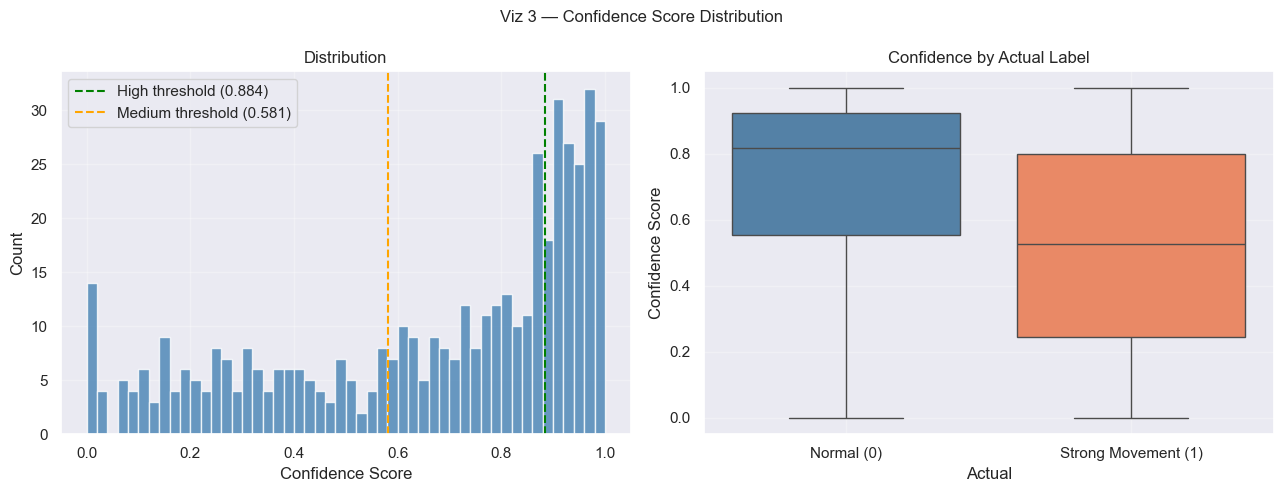

Saved → ../reports/figures/nb5/viz3_confidence_distribution.png


In [9]:
# ── Viz 3: Confidence Score Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Viz 3 — Confidence Score Distribution', fontsize=12)

# Histogram
axes[0].hist(Confidence, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(thr_high, color='green',  lw=1.5, ls='--', label=f'High threshold ({thr_high:.3f})')
axes[0].axvline(thr_med,  color='orange', lw=1.5, ls='--', label=f'Medium threshold ({thr_med:.3f})')
axes[0].set_title('Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box per actual label
plot_df = pd.DataFrame({'Confidence': Confidence, 'Actual': y_true})
sns.boxplot(data=plot_df, x='Actual', y='Confidence',
            hue='Actual', palette={0: 'steelblue', 1: 'coral'},
            legend=False, ax=axes[1])
axes[1].set_title('Confidence by Actual Label')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Normal (0)', 'Strong Movement (1)'])
axes[1].set_ylabel('Confidence Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz3_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz3_confidence_distribution.png')

In [10]:
df.groupby('Confidence_Bucket').agg({
    'Confidence':'mean',
    'Actual':'mean',
    'Predictive_Mean':'mean'
}).round(3)

,Confidence,Actual,Predictive_Mean
Confidence_Bucket,,,
High,0.946,0.108,0.099
Low,0.283,0.373,0.421
Medium,0.759,0.186,0.187


## 5. Phase 3 — Confidence Bucket Analysis

**Giả thuyết cốt lõi** của đồ án: mô hình có khả năng tự nhận biết khi nào nó đáng tin cậy.

Nếu Confidence Score được xây dựng đúng, ta kỳ vọng:

$$\text{Accuracy}(\text{High}) > \text{Accuracy}(\text{Medium}) > \text{Accuracy}(\text{Low})$$

Tức là: khi mô hình nói "tôi confident", dự đoán đó phải chính xác hơn khi nó nói "tôi uncertain".

Đây là tính chất **monotonicity** — bằng chứng quan trọng để kết luận Confidence Score có giá trị thực tiễn trong pipeline đánh giá độ tin cậy dữ liệu.

In [11]:
BUCKET_ORDER  = ['High', 'Medium', 'Low']
BUCKET_COLORS = {'High': '#27ae60', 'Medium': '#f39c12', 'Low': '#e74c3c'}

bucket_results = []
for bucket in BUCKET_ORDER:
    mask = df['Confidence_Bucket'] == bucket
    sub  = df[mask]
    if len(sub) == 0:
        continue
    yt = sub['Actual'].values
    yp = sub['Prediction'].values
    bucket_results.append({
        'Bucket'    : bucket,
        'N'         : len(sub),
        'Accuracy'  : accuracy_score(yt, yp),
        'Precision' : precision_score(yt, yp, zero_division=0),
        'Recall'    : recall_score(yt, yp, zero_division=0),
        'F1'        : f1_score(yt, yp, zero_division=0),
        'F2'        : fbeta_score(yt, yp, beta=2, zero_division=0),
        'Mean_Conf' : sub['Confidence'].mean(),
        'Mean_Var'  : sub['Predictive_Variance'].mean()
    })

bucket_df = pd.DataFrame(bucket_results)
print('=== Performance by Confidence Bucket ===')
print(bucket_df.round(4).to_string(index=False))
print()

# Kiểm tra tính đơn điệu (monotonicity)
if len(bucket_df) == 3:
    acc_h = bucket_df.loc[bucket_df.Bucket=='High',   'Accuracy'].values[0]
    acc_m = bucket_df.loc[bucket_df.Bucket=='Medium', 'Accuracy'].values[0]
    acc_l = bucket_df.loc[bucket_df.Bucket=='Low',    'Accuracy'].values[0]
    f2_h  = bucket_df.loc[bucket_df.Bucket=='High',   'F2'].values[0]
    f2_m  = bucket_df.loc[bucket_df.Bucket=='Medium', 'F2'].values[0]
    f2_l  = bucket_df.loc[bucket_df.Bucket=='Low',    'F2'].values[0]
    monotone_acc = (acc_h > acc_m) and (acc_m > acc_l)
    monotone_f2  = (f2_h  > f2_m)  and (f2_m  > f2_l)
    print(f'Monotonicity — Accuracy: {acc_h:.3f} > {acc_m:.3f} > {acc_l:.3f}  → {"✓ ĐÚNG" if monotone_acc else "⚠ Không hoàn toàn"}')
    print(f'Monotonicity — F2      : {f2_h:.3f} > {f2_m:.3f} > {f2_l:.3f}  → {"✓ ĐÚNG" if monotone_f2  else "⚠ Không hoàn toàn"}')

=== Performance by Confidence Bucket ===
Bucket   N  Accuracy  Precision  Recall     F1     F2  Mean_Conf  Mean_Var
  High 158    0.8987     1.0000  0.0588 0.1111 0.0725     0.9456    0.0010
Medium 161    0.5342     0.2581  0.8000 0.3902 0.5634     0.7586    0.0034
   Low 158    0.3734     0.3734  1.0000 0.5438 0.7487     0.2831    0.0168

Monotonicity — Accuracy: 0.899 > 0.534 > 0.373  → ✓ ĐÚNG
Monotonicity — F2      : 0.072 > 0.563 > 0.749  → ⚠ Không hoàn toàn


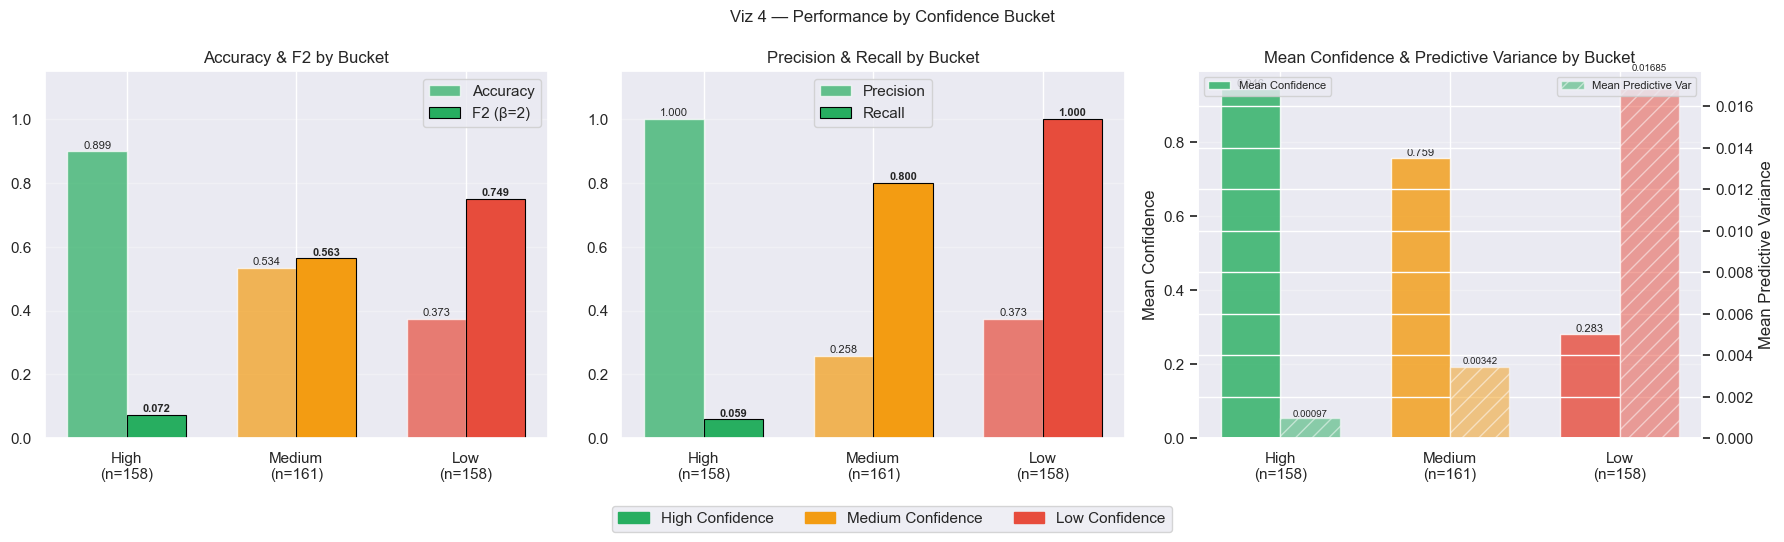

Saved → ../reports/figures/nb5/viz4_bucket_performance.png


In [12]:
# ── Viz 4: Performance by Confidence Bucket ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Viz 4 — Performance by Confidence Bucket', fontsize=12)

colors_ordered = [BUCKET_COLORS[b] for b in bucket_df['Bucket']]
x = np.arange(len(bucket_df))
w = 0.35
labels_x = [f"{b}\n(n={int(n)})" for b, n in zip(bucket_df['Bucket'], bucket_df['N'])]

# Panel 1: Accuracy & F2
bars1 = axes[0].bar(x - w/2, bucket_df['Accuracy'], w, color=colors_ordered, alpha=0.7, label='Accuracy')
bars2 = axes[0].bar(x + w/2, bucket_df['F2'],       w, color=colors_ordered, alpha=1.0,
                    label='F2 (β=2)', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars1, bucket_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, bucket_df['F2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x)
axes[0].set_title('Accuracy & F2 by Bucket')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Panel 2: Precision & Recall
bars3 = axes[1].bar(x - w/2, bucket_df['Precision'], w, color=colors_ordered, alpha=0.7, label='Precision')
bars4 = axes[1].bar(x + w/2, bucket_df['Recall'],    w, color=colors_ordered, alpha=1.0,
                    label='Recall', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars3, bucket_df['Precision']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars4, bucket_df['Recall']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_x)
axes[1].set_title('Precision & Recall by Bucket')
axes[1].set_ylim(0, 1.15)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# Panel 3: Mean Confidence & Mean Variance
ax3 = axes[2]
color3 = [BUCKET_COLORS[b] for b in bucket_df['Bucket']]
bars5 = ax3.bar(x - w/2, bucket_df['Mean_Conf'], w, color=color3, alpha=0.8, label='Mean Confidence')
ax3b = ax3.twinx()
bars6 = ax3b.bar(x + w/2, bucket_df['Mean_Var'], w, color=color3, alpha=0.5,
                 label='Mean Predictive Var', hatch='//')
for bar, val in zip(bars5, bucket_df['Mean_Conf']):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars6, bucket_df['Mean_Var']):
    ax3b.text(bar.get_x() + bar.get_width()/2, val*1.05, f'{val:.5f}', ha='center', fontsize=7)
ax3.set_xticks(x)
ax3.set_xticklabels(labels_x)
ax3.set_title('Mean Confidence & Predictive Variance by Bucket')
ax3.set_ylabel('Mean Confidence')
ax3b.set_ylabel('Mean Predictive Variance')
ax3.legend(loc='upper left', fontsize=8)
ax3b.legend(loc='upper right', fontsize=8)
ax3.grid(alpha=0.3, axis='y')

handles = [mpatches.Patch(color=BUCKET_COLORS[b], label=f'{b} Confidence') for b in BUCKET_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz4_bucket_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz4_bucket_performance.png')

In [13]:
print("\nActual Label Distribution by Confidence Bucket")
display(
    pd.crosstab(
        df['Confidence_Bucket'],
        df['Actual'],
        normalize='index'
    ).round(3)
)


Actual Label Distribution by Confidence Bucket


Actual,0,1
Confidence_Bucket,,
High,0.892,0.108
Low,0.627,0.373
Medium,0.814,0.186


## 6. Phase 4 — Correct vs Incorrect Variance Analysis

**Giả thuyết:** mô hình Bayesian có xu hướng có Predictive Variance **cao hơn** ở những dự đoán sai.

$$\mathbb{E}[\text{Var} \mid \text{Incorrect}] > \mathbb{E}[\text{Var} \mid \text{Correct}]$$

Nếu đúng, điều này xác nhận rằng **Predictive Variance là một tín hiệu đáng tin cậy về chất lượng dự đoán** — uncertainty cao → nên cẩn thận hơn khi ra quyết định dựa trên prediction đó.

In [14]:
df['Correct'] = (df['Prediction'] == df['Actual']).astype(int)

var_correct   = df.loc[df['Correct']==1, 'Predictive_Variance'].values
var_incorrect = df.loc[df['Correct']==0, 'Predictive_Variance'].values

ratio = var_incorrect.mean() / (var_correct.mean() + 1e-10)

print('=== Var(Incorrect) vs Var(Correct) ===')
print(f'Correct   n={len(var_correct)}  mean={var_correct.mean():.6f}  median={np.median(var_correct):.6f}')
print(f'Incorrect n={len(var_incorrect)}  mean={var_incorrect.mean():.6f}  median={np.median(var_incorrect):.6f}')
print(f'Ratio Var(Incorrect)/Var(Correct) = {ratio:.3f}x')
print(f'Kỳ vọng: {"✓ ĐÚNG — Var(Incorrect) > Var(Correct)" if ratio > 1 else "✗ Không đúng kỳ vọng"}')

=== Var(Incorrect) vs Var(Correct) ===
Correct   n=287  mean=0.004690  median=0.001581
Incorrect n=190  mean=0.010626  median=0.007281
Ratio Var(Incorrect)/Var(Correct) = 2.266x
Kỳ vọng: ✓ ĐÚNG — Var(Incorrect) > Var(Correct)


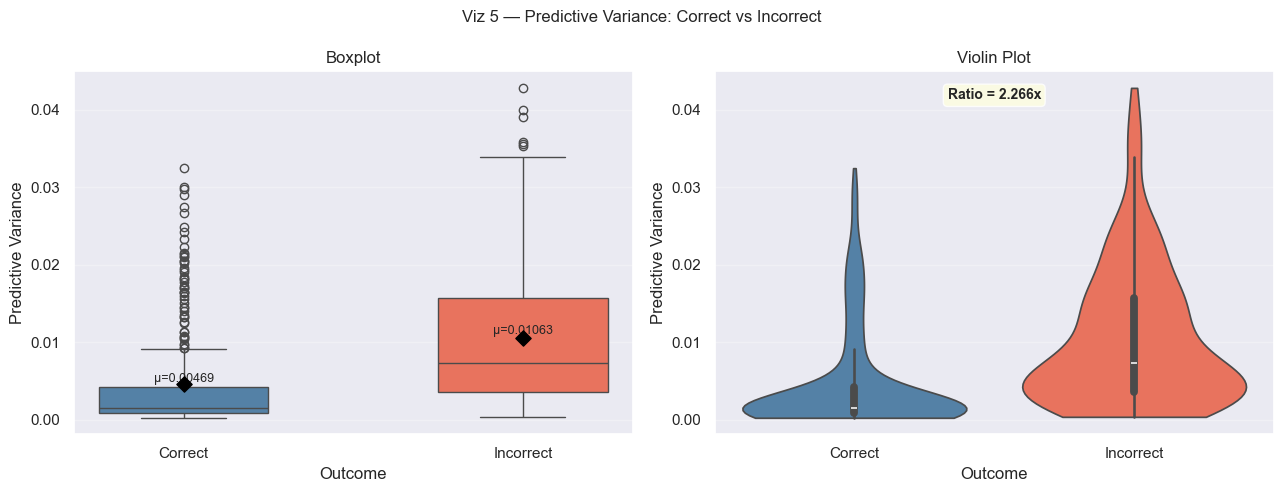

Saved → ../reports/figures/nb5/viz5_variance_correct_incorrect.png


In [15]:
# ── Viz 5: Boxplot Variance by Outcome ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Viz 5 — Predictive Variance: Correct vs Incorrect', fontsize=12)

plot_df = pd.DataFrame({
    'Predictive_Variance': df['Predictive_Variance'].values,
    'Outcome': ['Correct' if c == 1 else 'Incorrect' for c in df['Correct']]
})

palette = {'Correct': 'steelblue', 'Incorrect': 'tomato'}

sns.boxplot(data=plot_df, x='Outcome', y='Predictive_Variance',
            palette=palette, width=0.5, ax=axes[0], order=['Correct', 'Incorrect'])
for i, (outcome, grp) in enumerate(plot_df.groupby('Outcome')):
    m = grp['Predictive_Variance'].mean()
    idx_bar = 0 if outcome == 'Correct' else 1
    axes[0].scatter(idx_bar, m, color='black', zorder=5, s=60, marker='D')
    axes[0].text(idx_bar, m*1.04, f'μ={m:.5f}', ha='center', fontsize=9)
axes[0].set_title('Boxplot')
axes[0].set_ylabel('Predictive Variance')
axes[0].grid(alpha=0.3, axis='y')

sns.violinplot(data=plot_df, x='Outcome', y='Predictive_Variance',
               palette=palette, ax=axes[1], order=['Correct', 'Incorrect'],
               inner='box', cut=0)
axes[1].text(0.5, axes[1].get_ylim()[1]*0.92,
             f'Ratio = {ratio:.3f}x', ha='center', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].set_title('Violin Plot')
axes[1].set_ylabel('Predictive Variance')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz5_variance_correct_incorrect.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz5_variance_correct_incorrect.png')

## 6b. Viz 6 — Posterior Predictive CI theo thời gian, tô màu theo Confidence Bucket

Kết hợp hai thông tin: **posterior predictive mean + CI** (từ NB4) với **confidence bucket** (từ NB5).
Màu của CI band phản ánh độ tin cậy: 🟢 High → 🟡 Medium → 🔴 Low.

Biểu đồ này trả lời câu hỏi: *"Ở những thời điểm nào trong validation period thì mô hình confident/uncertain?"*

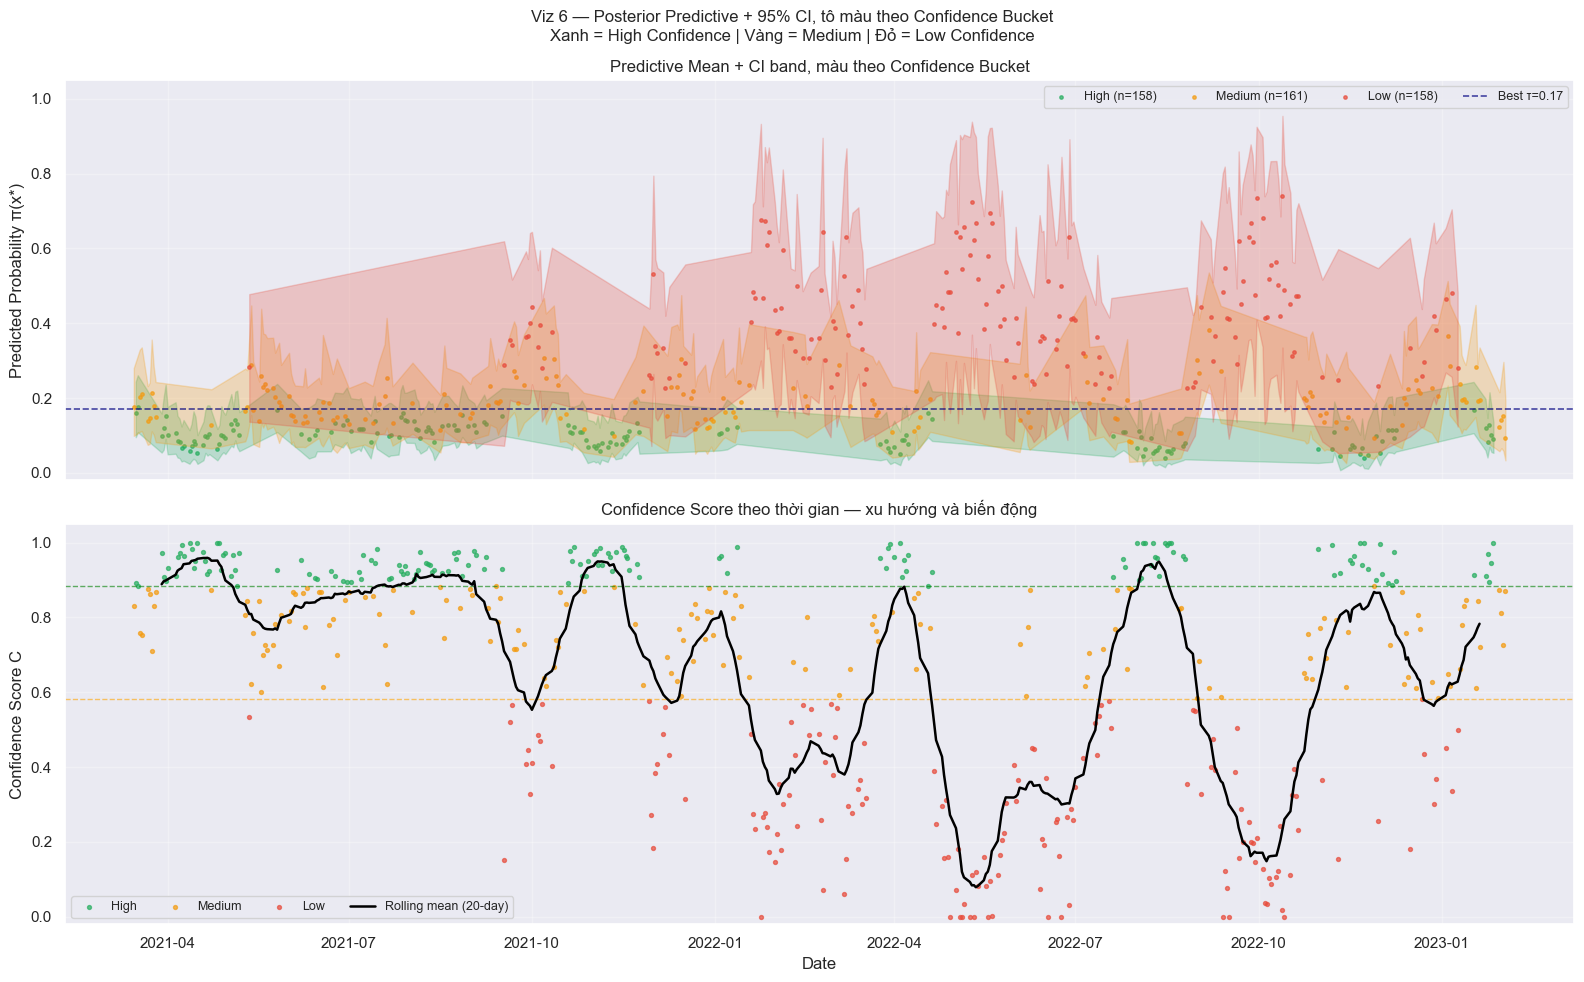

Saved → ../reports/figures/nb5/viz6_ci_timeseries_by_bucket.png


In [16]:
# ── Viz 6: CI Time Series tô màu theo Confidence Bucket ────────────────────
BUCKET_PALETTE = {'High': '#27ae60', 'Medium': '#f39c12', 'Low': '#e74c3c'}

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(
    'Viz 6 — Posterior Predictive + 95% CI, tô màu theo Confidence Bucket\n'
    'Xanh = High Confidence | Vàng = Medium | Đỏ = Low Confidence',
    fontsize=12
)

ax = axes[0]
for bucket, color in BUCKET_PALETTE.items():
    mask = df['Confidence_Bucket'] == bucket
    sub  = df[mask]
    if len(sub) == 0:
        continue
    ax.fill_between(sub.index, sub['CI_Lower'].values, sub['CI_Upper'].values,
                    alpha=0.25, color=color)
    ax.scatter(sub.index, sub['Predictive_Mean'].values, color=color, s=6, alpha=0.7,
               label=f'{bucket} (n={mask.sum()})')

ax.axhline(BEST_THRESHOLD, color='navy', lw=1.2, ls='--', alpha=0.7,
           label=f'Best τ={BEST_THRESHOLD}')
ax.set_ylabel('Predicted Probability π(x*)')
ax.set_title('Predictive Mean + CI band, màu theo Confidence Bucket')
ax.set_ylim(-0.02, 1.05)
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
for bucket, color in BUCKET_PALETTE.items():
    mask = df['Confidence_Bucket'] == bucket
    sub  = df[mask]
    if len(sub) == 0:
        continue
    ax2.scatter(sub.index, sub['Confidence'].values,
                color=color, s=8, alpha=0.7, label=bucket)

rolling_conf = df['Confidence'].rolling(window=20, center=True).mean()
ax2.plot(rolling_conf.index, rolling_conf.values, color='black', lw=1.8,
         label='Rolling mean (20-day)', zorder=5)
ax2.axhline(thr_high, color='green',  lw=1, ls='--', alpha=0.6)
ax2.axhline(thr_med,  color='orange', lw=1, ls='--', alpha=0.6)
ax2.set_xlabel('Date')
ax2.set_ylabel('Confidence Score C')
ax2.set_title('Confidence Score theo thời gian — xu hướng và biến động')
ax2.set_ylim(-0.02, 1.05)
ax2.legend(ncol=4, fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz6_ci_timeseries_by_bucket.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz6_ci_timeseries_by_bucket.png')

## 6c. Viz 7 — Expected Calibration Error (ECE) & Reliability Diagram

**Calibration** đo lường: khi mô hình nói $\pi(x^*)=0.7$, thực tế có ~70% là positive không?

Một mô hình **well-calibrated** có xác suất dự đoán có nghĩa thực tế — có thể dùng trực tiếp để ra quyết định mà không cần chuyển đổi thêm.

**Expected Calibration Error (ECE):**

$$\text{ECE} = \sum_{b=1}^{B} \frac{|\mathcal{B}_b|}{N} \left|\text{acc}(\mathcal{B}_b) - \text{conf}(\mathcal{B}_b)\right|$$

- $\mathcal{B}_b$: tập observations có predicted probability rơi vào bin $b$.
- $\text{acc}(\mathcal{B}_b)$: tỷ lệ positive thực tế trong bin $b$.
- $\text{conf}(\mathcal{B}_b)$: mean predicted probability trong bin $b$.
- ECE = trung bình có trọng số của khoảng cách giữa confidence và accuracy.

**Kỳ vọng Bayesian:** ECE(High bucket) < ECE(Low bucket) — khi mô hình confident, calibration tốt hơn.

ECE thấp → mô hình well-calibrated → xác suất dự đoán đáng tin cậy.

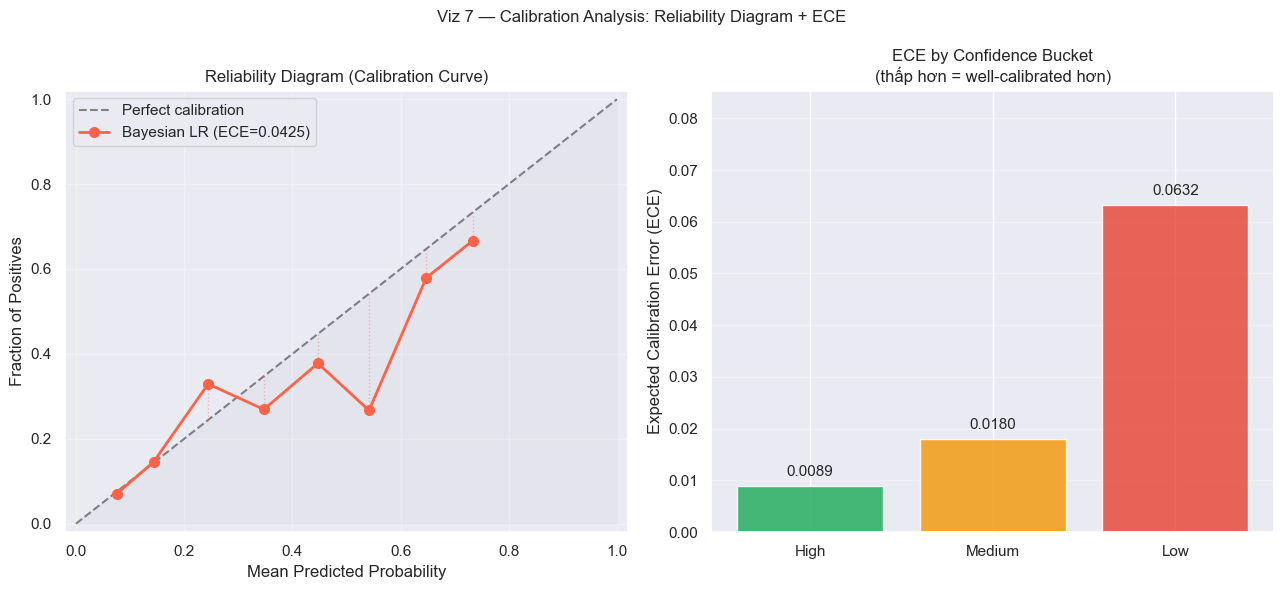

=== Calibration Summary ===
ECE (overall)   : 0.0425
Brier Score     : 0.1602
ECE by bucket   :
  High    : 0.0089
  Medium  : 0.0180
  Low     : 0.0632

Kỳ vọng Bayesian: ECE(High) < ECE(Medium) < ECE(Low)
→ Khi model confident (High bucket), calibration tốt hơn
Saved → ../reports/figures/nb5/viz7_calibration_ece.png


In [17]:
# ── Viz 7: ECE + Reliability Diagram ───────────────────────────────────────
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_prob_val = df['Predictive_Mean'].values
y_true_val = df['Actual'].values

frac_pos, mean_pred = calibration_curve(y_true_val, y_prob_val, n_bins=10)

def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — đo độ lệch giữa confidence và accuracy."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    n    = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return ece

ece_blr   = compute_ece(y_true_val, y_prob_val)
brier_blr = brier_score_loss(y_true_val, y_prob_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Viz 7 — Calibration Analysis: Reliability Diagram + ECE', fontsize=12)

ax = axes[0]
ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(mean_pred, frac_pos, 'o-', color='tomato', lw=2, ms=7,
        label=f'Bayesian LR (ECE={ece_blr:.4f})')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
for mp, fp in zip(mean_pred, frac_pos):
    ax.plot([mp, mp], [mp, fp], color='tomato', lw=1, alpha=0.4, ls=':')
ax.set_title('Reliability Diagram (Calibration Curve)')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
bucket_ece = {}
for bucket in ['High', 'Medium', 'Low']:
    mask = df['Confidence_Bucket'] == bucket
    if mask.sum() < 5:
        continue
    yt = df.loc[mask, 'Actual'].values
    yp = df.loc[mask, 'Predictive_Mean'].values
    bucket_ece[bucket] = compute_ece(yt, yp, n_bins=5)

colors_bar = [BUCKET_PALETTE[b] for b in bucket_ece.keys()]
ax2.bar(list(bucket_ece.keys()), list(bucket_ece.values()),
        color=colors_bar, alpha=0.85, edgecolor='white')
for i, (b, val) in enumerate(bucket_ece.items()):
    ax2.text(i, val + 0.002, f'{val:.4f}', ha='center', fontsize=11)
ax2.set_title('ECE by Confidence Bucket\n(thấp hơn = well-calibrated hơn)')
ax2.set_ylabel('Expected Calibration Error (ECE)')
ax2.set_ylim(0, max(bucket_ece.values()) * 1.35 if bucket_ece else 0.1)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz7_calibration_ece.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'=== Calibration Summary ===')
print(f'ECE (overall)   : {ece_blr:.4f}')
print(f'Brier Score     : {brier_blr:.4f}')
print(f'ECE by bucket   :')
for b, v in bucket_ece.items():
    print(f'  {b:<8}: {v:.4f}')
print()
print('Kỳ vọng Bayesian: ECE(High) < ECE(Medium) < ECE(Low)')
print('→ Khi model confident (High bucket), calibration tốt hơn')
print(f'Saved → {FIGURES_DIR}/viz7_calibration_ece.png')

## 7. Export Output

In [18]:
# ── Xây dựng bayesian_decision_dataset ─────────────────────────────────────
out_df = pd.DataFrame({
    'Actual'             : df['Actual'].values,
    'Predictive_Mean'    : df['Predictive_Mean'].values,
    'Predictive_Variance': df['Predictive_Variance'].values,
    'CI_Lower'           : df['CI_Lower'].values,
    'CI_Upper'           : df['CI_Upper'].values,
    'CI_Width'           : df['CI_Width'].values,
    'Confidence'         : df['Confidence'].values,
    'Prediction'         : df['Prediction'].values,
    'Confidence_Bucket'  : df['Confidence_Bucket'].values,
    'Correct'            : (df['Prediction'] == df['Actual']).astype(int)
}, index=df.index)
out_df.index.name = 'Date'

out_df.to_csv(f'{PROCESSED_DIR}/bayesian_decision_dataset.csv')
print(f'✓ Saved → {PROCESSED_DIR}/bayesian_decision_dataset.csv')
print(f'  Shape: {out_df.shape}')

# ── Lưu threshold info JSON — đồng bộ F2 ────────────────────────────────────
threshold_info = {
    'best_threshold'          : round(BEST_THRESHOLD, 4),
    'threshold_metric'        : 'F2 (beta=2)',
    'best_f2'                 : round(best_f2, 4),
    'best_f1'                 : round(best_f1, 4),
    'best_precision'          : round(best_precision, 4),
    'best_recall'             : round(best_recall, 4),
    'auprc'                   : round(float(auprc), 4),
    'confidence_normalization': 'robust quantile normalization: (U - p2.5) / (p97.5 - p2.5)',
    'bucket_method'           : 'tertile (data-driven)',
    'bucket_thresholds'       : {
        'High'  : f'>={thr_high:.4f}  (67th percentile)',
        'Medium': f'[{thr_med:.4f}, {thr_high:.4f})',
        'Low'   : f'<{thr_med:.4f}  (33rd percentile)'
    }
}

with open(f'{RESULTS_DIR}/bayesian_threshold.json', 'w') as fout:
    json.dump(threshold_info, fout, indent=4)
print(f'✓ Saved → {RESULTS_DIR}/bayesian_threshold.json')
print(json.dumps(threshold_info, indent=4))

✓ Saved → ../data/processed/bayesian_decision_dataset.csv
  Shape: (477, 10)
✓ Saved → ../results/bayesian/bayesian_threshold.json
{
    "best_threshold": 0.17,
    "threshold_metric": "F2 (beta=2)",
    "best_f2": 0.6213,
    "best_f1": 0.4693,
    "best_precision": 0.3333,
    "best_recall": 0.7925,
    "auprc": 0.397,
    "confidence_normalization": "robust quantile normalization: (U - p2.5) / (p97.5 - p2.5)",
    "bucket_method": "tertile (data-driven)",
    "bucket_thresholds": {
        "High": ">=0.8839  (67th percentile)",
        "Medium": "[0.5815, 0.8839)",
        "Low": "<0.5815  (33rd percentile)"
    }
}
